# Estimation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode
from scipy.constants import pound

Weighing Penguins

In [2]:
sample = pd.Series(np.random.normal(0, 1, size=5000))
sample

0       1.849809
1       0.538251
2       1.704837
3       0.153516
4      -0.591301
          ...   
4995   -0.220236
4996    1.098461
4997    0.350764
4998   -0.412883
4999   -0.516133
Length: 5000, dtype: float64

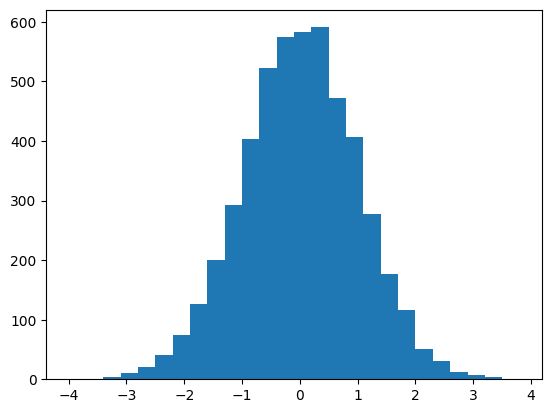

In [3]:
fig, ax = plt.subplots()
ax.hist(sample, bins=np.arange(-4, 4, 0.3))
plt.show()

In [4]:
np.mean(sample), np.std(sample)

(np.float64(0.006899587363736987), np.float64(0.9997350310610483))

We didn't have to show it in graph but we can totally say that `np.random.normal` creates normally distributed numbers.

In [5]:
def make_normal_sample(mu, sigma, n):
    return np.random.normal(mu, sigma, n)

In [6]:
ns = np.logspace(1, 5).astype(int)

We are going to use these `n`s to see how the _estimator_ changes when the sample size increases.

In [7]:
mu = 3.7
sigma = 0.46

In [8]:
means = [np.mean(make_normal_sample(mu, sigma, n)) for n in ns]
medians = [np.median(make_normal_sample(mu, sigma, n)) for n in ns]

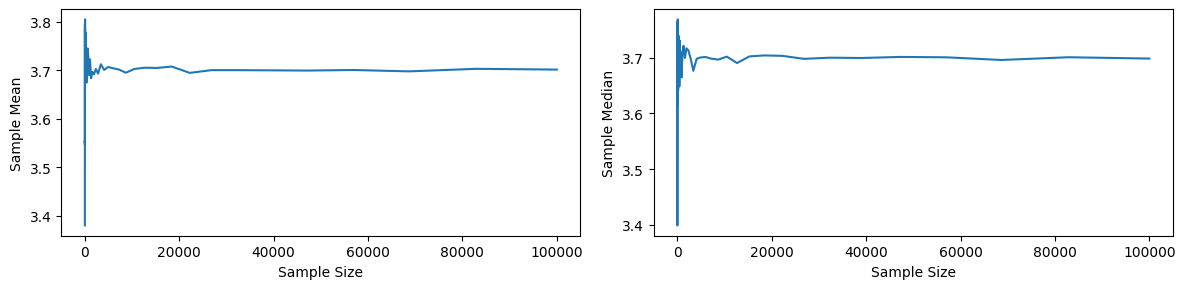

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ns, means)
axes[1].plot(ns, medians)
axes[0].set_ylabel("Sample Mean")
axes[0].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Median")
axes[1].set_xlabel("Sample Size")
plt.tight_layout()
plt.show()

Right here, we've visualized the WLLN (Weak Law of Large Numbers) in action. We can also see that in a normal distribution, mean, median and the mode are perfectly equal in a normal distribution. But using the mean is usually preferred here because it is more statistically efficient.

**What is an estimator?** Simply put, an estimator is a rule or formula used to make an educated guess about a population parameter (like the mean, standard deviation, or median) based on sample data. When an estimator gets closer to the true population parameter as the sample size goes to infinity, we specifically call it a consistent estimator.

Before diving into deeper topics, I just want to clarify that we are currently focusing on central tendency measures. While all of these are useful under the right conditions, picking the most useful may depend on the question we’re asking. Let’s illustrate this with a real-world example.

If we plotted a histogram of global wealth, we would see a right-skewed distribution (Lognormal is our best choice here). This happens because the vast majority of people earn roughly the same average income, while a tiny fraction of the population holds an extreme amount of wealth.

In [10]:
income = np.random.lognormal(9, 2.1, size=1_000_000)
bins = np.linspace(0, 200_000, 100)

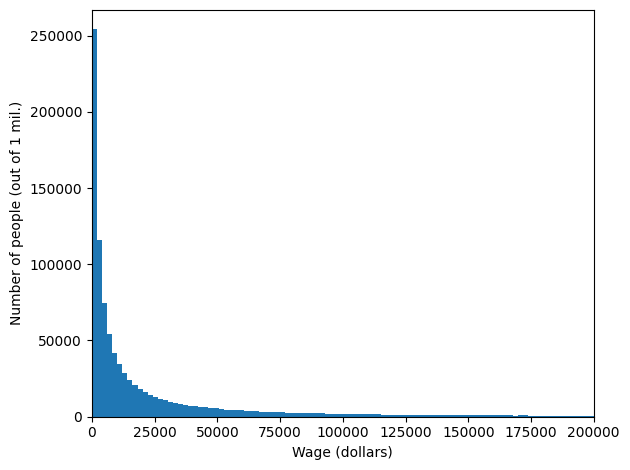

In [11]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
plt.tight_layout()
plt.show()

Let's also visualize the mean, median and the mode of this distribution.

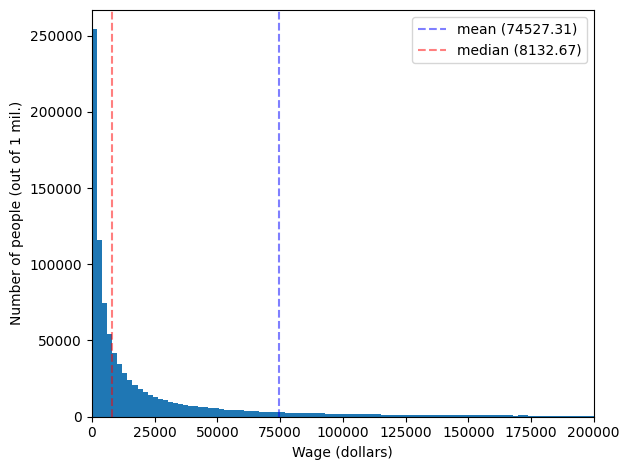

In [12]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.axvline(
    np.mean(income),
    linestyle="--",
    color="blue",
    alpha=0.5,
    label=f"mean ({np.mean(income):.2f})",
)
ax.axvline(
    np.median(income),
    linestyle="--",
    color="red",
    alpha=0.5,
    label=f"median ({np.median(income):.2f})",
)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
ax.legend()
plt.tight_layout()
plt.show()

So comparing the mean and the median, which one would be closer to the answer we would get if we asked people about their wages? It would probably be the median value. Because the mean is very sensitive to outliers, and we have ultra-rich people in the distribution, we cannot rely on it.

So what does this have to do with estimation? Nothing. I just wanted to make it clearer that the fact we can obtain the same result using both the mean and the median above is a property of the normal distribution. Let's keep going with the estmiation.

Let's check out means and medians first.

In [13]:
means[:5], medians[:5]

([np.float64(3.3803856248396102),
  np.float64(3.555386457916766),
  np.float64(3.5500451748160438),
  np.float64(3.7927553769681444),
  np.float64(3.7956214731285605)],
 [np.float64(3.619065290532922),
  np.float64(3.3990915555540697),
  np.float64(3.467258877210049),
  np.float64(3.5577711641845298),
  np.float64(3.647458183179721)])

We are sure that both mean and the median is a great estimators, but let's take a look at the RMSE (Root Mean Sqaure Error) of both estimates.

In [14]:
def mse(estimates, actual):
    errors = np.asarray(estimates) - actual
    return np.mean(errors**2)

In [15]:
means_rmse = np.sqrt(mse(means, mu))
medians_rmse = np.sqrt(mse(medians, mu))
means_rmse, medians_rmse

(np.float64(0.06723285772373455), np.float64(0.06484903907438652))

It looks like the RMSE of means is lower, which means the deviation of the sample means is lower compared to deviation of the sample medians.

## Robustness

The `mu` and the `sigma` we use here are from an imaginary penguin weight dataset.

If we expand on the scenario, we take the penguins, weigh them, and record their weights. However, let’s say that 2% of the penguins accidentally pressed the “unit” button, and some of them were measured in kilograms instead of pounds.

In [16]:
def make_normal_sample_with_errors(mu, sigma, n):
    sample = np.random.normal(mu, sigma, n)
    factor = np.random.choice([1, 1 / pound], p=[0.98, 0.02], size=n)
    return factor * sample

In [17]:
sample = make_normal_sample_with_errors(mu, sigma, 5000)
sample_pdf = pd.Series(sample).value_counts(normalize=True)

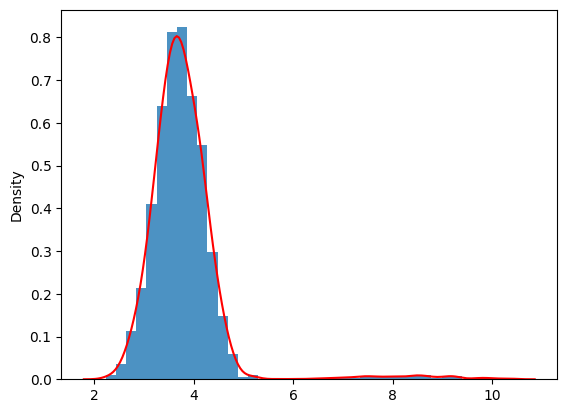

In [18]:
fig, ax = plt.subplots()
ax.hist(sample, bins=40, density=True, alpha=0.8)
sns.kdeplot(sample, ax=ax, color="red")
plt.show()

As we can see, the outliers are causing the plot to extend to the right. Let's see which estimator is unbiased with the faulty dataset.

In [19]:
ns = np.logspace(1, 5).astype(int)
faulty_means = [np.mean(make_normal_sample_with_errors(mu, sigma, n)) for n in ns]
faulty_medians = [np.median(make_normal_sample_with_errors(mu, sigma, n)) for n in ns]

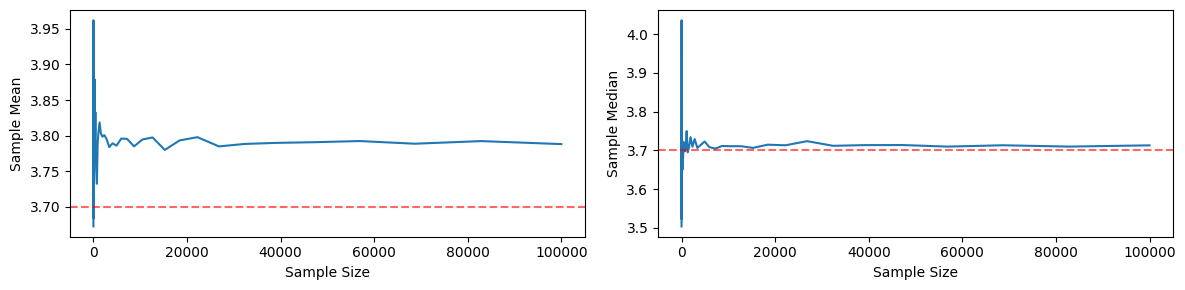

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ns, faulty_means)
axes[1].plot(ns, faulty_medians)
axes[0].axhline(mu, linestyle="--", color="red", alpha=0.6)
axes[1].axhline(mu, linestyle="--", color="red", alpha=0.6)
axes[0].set_ylabel("Sample Mean")
axes[0].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Median")
axes[1].set_xlabel("Sample Size")
plt.tight_layout()
plt.show()

With the faulty dataset, median is the less biased estimator. That's because, as we've always been saying, the median is much more robust.